# Notebook to get an overview of the Data

In [ ]:
# Imports
import os
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Make sure that everyone has same dataset. Has to be in gitignore because toooo large
df = pd.read_csv('../data/Taxi_Trips_(2024-)_20260502.csv') 

In [5]:
df.head()

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,...,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,6c54cdb22905b181c23527e74c2b653a503107b7,db757f6c1157d9f81e266396132cd641837c189b803c52...,04/01/2026 12:00:00 AM,04/01/2026 12:15:00 AM,1.407,"14,35",NaN,NaN,76.0,22.0,...,"$5,00","$48,01",Credit Card,Flash Cab,"41,980264315","-87,913624596",POINT (-87.913624596 41.9802643146),"41,92276062","-87,699155343",POINT (-87.6991553432 41.9227606205)
1,6cd5d74b7ec8d7d230387900d72d74326dfb31de,f509c57d2f0b196f54d9b751ce2a1b6e956f378841b1e8...,04/01/2026 12:00:00 AM,04/01/2026 12:15:00 AM,1.701,"19,14",1.703198e+10,1.703132e+10,76.0,32.0,...,"$0,00","$60,50",Credit Card,City Service,"41,97907082","-87,903039661",POINT (-87.9030396611 41.9790708201),"41,884987192","-87,620992913",POINT (-87.6209929134 41.8849871918)
2,d36a90d961ed60add20ab3a4a7a8ca98bd2bf929,4136627ef25b9fad79910c55679c02d8e1f2a42925d29c...,04/01/2026 12:00:00 AM,04/01/2026 12:15:00 AM,1.260,"10,2",NaN,NaN,76.0,14.0,...,"$4,00","$31,25",Cash,Transit Administrative Center Inc,"41,980264315","-87,913624596",POINT (-87.913624596 41.9802643146),"41,968069","-87,721559063",POINT (-87.7215590627 41.968069)
3,cb1fed57e7eeea1db20758256b754201f5e13e07,c9bda81f1aaad786527911c983b6be11f28c6f46469e1a...,04/01/2026 12:00:00 AM,04/01/2026 12:30:00 AM,1.608,"18,4",NaN,NaN,76.0,32.0,...,"$5,00","$50,50",Credit Card,Taxicab Insurance Agency Llc,"41,980264315","-87,913624596",POINT (-87.913624596 41.9802643146),"41,878865584","-87,625192142",POINT (-87.6251921424 41.8788655841)
4,d3c33c166fdbca45d040772d18bd1ae1dc669ade,f71223a469d78a2f65a090adc9d4fb5ae08dfc6694c650...,04/01/2026 12:00:00 AM,04/01/2026 12:00:00 AM,422.000,"0,98",NaN,NaN,32.0,28.0,...,"$0,00","$6,00",Cash,Chicago Independents,"41,878865584","-87,625192142",POINT (-87.6251921424 41.8788655841),"41,874005383","-87,66351755",POINT (-87.6635175498 41.874005383)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14802849 entries, 0 to 14802848
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Trip ID                     str    
 1   Taxi ID                     str    
 2   Trip Start Timestamp        str    
 3   Trip End Timestamp          str    
 4   Trip Seconds                float64
 5   Trip Miles                  str    
 6   Pickup Census Tract         float64
 7   Dropoff Census Tract        float64
 8   Pickup Community Area       float64
 9   Dropoff Community Area      float64
 10  Fare                        str    
 11  Tips                        str    
 12  Tolls                       str    
 13  Extras                      str    
 14  Trip Total                  str    
 15  Payment Type                str    
 16  Company                     str    
 17  Pickup Centroid Latitude    str    
 18  Pickup Centroid Longitude   str    
 19  Pickup Centroid Location    st

In [7]:
df.columns

Index(['Trip ID', 'Taxi ID', 'Trip Start Timestamp', 'Trip End Timestamp',
       'Trip Seconds', 'Trip Miles', 'Pickup Census Tract',
       'Dropoff Census Tract', 'Pickup Community Area',
       'Dropoff Community Area', 'Fare', 'Tips', 'Tolls', 'Extras',
       'Trip Total', 'Payment Type', 'Company', 'Pickup Centroid Latitude',
       'Pickup Centroid Longitude', 'Pickup Centroid Location',
       'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude',
       'Dropoff Centroid  Location'],
      dtype='str')

In [8]:
df.isnull().sum()

Trip ID                             0
Taxi ID                            11
Trip Start Timestamp                0
Trip End Timestamp                329
Trip Seconds                     2847
Trip Miles                        123
Pickup Census Tract           8237431
Dropoff Census Tract          8435004
Pickup Community Area          413385
Dropoff Community Area        1320108
Fare                            31160
Tips                            31160
Tolls                           31160
Extras                          31160
Trip Total                      31160
Payment Type                        0
Company                             0
Pickup Centroid Latitude       405819
Pickup Centroid Longitude      405819
Pickup Centroid Location       405819
Dropoff Centroid Latitude     1241359
Dropoff Centroid Longitude    1241359
Dropoff Centroid  Location    1241359
dtype: int64

lot of Data is null because of privacy reasons:
- Pickup Census Tract           8237431
- Dropoff Census Tract          8435004
- ...

In [22]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
missing.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
Dropoff Census Tract,8435004,56.98
Pickup Census Tract,8237431,55.65
Dropoff Community Area,1320108,8.92
Dropoff Centroid Longitude,1241359,8.39
Dropoff Centroid Location,1241359,8.39
Dropoff Centroid Latitude,1241359,8.39
Pickup Community Area,413385,2.79
Pickup Centroid Location,405819,2.74
Pickup Centroid Latitude,405819,2.74
Pickup Centroid Longitude,405819,2.74


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Trip ID"].duplicated().sum()

np.int64(0)

no duplicate trip ids, or rows

C:\Users\Georg\AppData\Local\Temp\ipykernel_724\3043268490.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Trip Start Timestamp"] = pd.to_datetime(df["Trip Start Timestamp"])


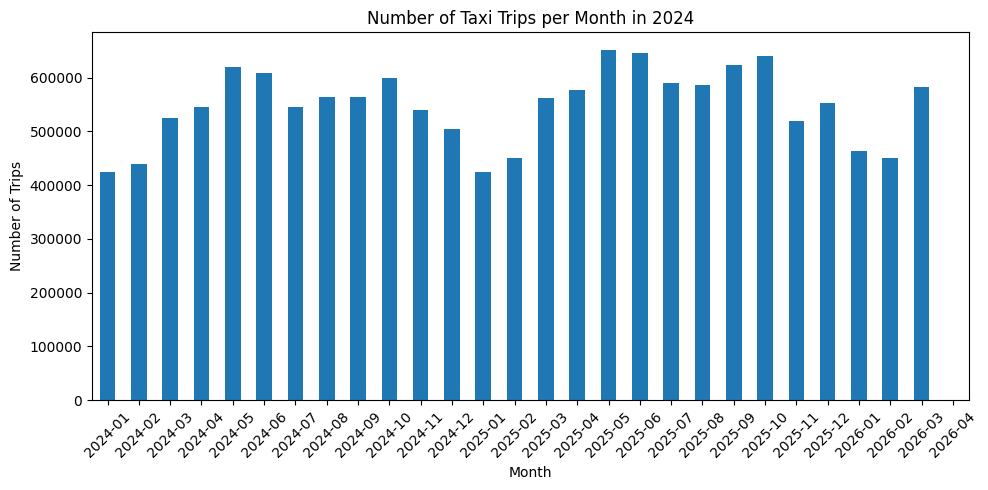

In [ ]:
df["Trip Start Timestamp"] = pd.to_datetime(df["Trip Start Timestamp"])

trips_per_month = (
    df["Trip Start Timestamp"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
trips_per_month.plot(kind="bar")
plt.title("Number of Taxi Trips per Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
feature = "Extras"

df[feature].dropna().unique()[:10].tolist()

['$5,00',
 '$0,00',
 '$4,00',
 '$2,00',
 '$12,00',
 '$10,00',
 '$17,00',
 '$5,50',
 '$26,00',
 '$6,00']

### How the Data needs to be prepared:

- Timestamp columns need to be converted from string/object format to datetime format.
- We have about 50% of null values in the features: `Dropoff Census Tract` & `Pickup Census Tract`. Not drop them, thats because of privacy reasons, just be aware of it.
- Some features have only 0.02-0.2% missing data. We can think about just dropping them maybe.
    - `Trip Total	    31160	0.21`
    - `Fare	            31160	0.21`
    - `Extras	        31160	0.21`
    - `Tolls	            31160	0.21`
    - `Tips	            31160	0.21`
    - `Trip Seconds	    2847	0.02`
- Convert numeric features to a numeric type like float, instead of str. Extras for example is str and looks like this: "$5,00".
- After converting datatypes: look for unrealistic values (i.e. negative traveltime, unrealistic values, ...) and outliers.
- Most important: clean with these steps the existing data, before creating new features.